In [2]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv('data/Car_Dataset.csv')
# Print the first 5 rows of the dataset
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
# Print the last 5 rows of the dataset
df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner


In [5]:
# Print 5 random samples from the dataset
df.sample(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
1548,Maruti Alto K10 LXI,2014,200999,40000,Petrol,Individual,Manual,First Owner
1538,Maruti Alto 800 LXI,2016,260000,45000,Petrol,Individual,Manual,Second Owner
2196,Chevrolet Tavera Neo 3 Max 9 Str BSIII,2014,400000,120000,Diesel,Individual,Manual,Second Owner
2815,Hyundai EON Magna Plus,2018,245000,30000,Petrol,Individual,Manual,First Owner
2688,Renault Duster 85PS Diesel RxL,2013,385000,80000,Diesel,Individual,Manual,Second Owner


In [6]:
# Print the shape of the dataset
df.shape

(4340, 8)

In [7]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 4340
Columns : 8


In [8]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [10]:
# Check for missing values
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [11]:
# Check the duplicted records in the dataset
df.duplicated().sum()

np.int64(763)

In [12]:
df.duplicated().sum()

np.int64(763)

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [16]:
df.describe(include = 'object')

,name,fuel,seller_type,transmission,owner
count,3577,3577,3577,3577,3577
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,54,1800,2832,3265,2218


In [17]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

print(f"Numerical Feature: {numerical_features}")
print(f"Categorical Feature: {categorical_features}")

Numerical Feature: ['year', 'selling_price', 'km_driven']
Categorical Feature: ['name', 'fuel', 'seller_type', 'transmission', 'owner']


In [18]:
for col in categorical_features:
    print(col)
    print(df[col].unique())
    print("=="*25)

name
<StringArray>
[                               'Maruti 800 AC',
                     'Maruti Wagon R LXI Minor',
                         'Hyundai Verna 1.6 SX',
                       'Datsun RediGO T Option',
                        'Honda Amaze VX i-DTEC',
                         'Maruti Alto LX BSIII',
                    'Hyundai Xcent 1.2 Kappa S',
                     'Tata Indigo Grand Petrol',
                     'Hyundai Creta 1.6 VTVT S',
                     'Maruti Celerio Green VXI',
 ...
                    'Honda Amaze S Petrol BSIV',
         'Hyundai Santro Xing XS eRLX Euro III',
                            'Hyundai Santro AT',
           'Ford Endeavour 2.2 Titanium AT 4X2',
                   'Chevrolet Spark 1.0 LT BS3',
                             'Maruti Swift LDI',
                                 'Tata Nano XM',
                 'Mahindra Verito 1.5 D6 BSIII',
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV',
                   'Hyundai i20 Magna 1.4 CRD

In [19]:
df['selling_price'].describe()

count    3.577000e+03
mean     4.739125e+05
std      5.093018e+05
min      2.000000e+04
25%      2.000000e+05
50%      3.500000e+05
75%      6.000000e+05
max      8.900000e+06
Name: selling_price, dtype: float64

In [20]:
df['selling_price'] = df['selling_price'].astype(int)

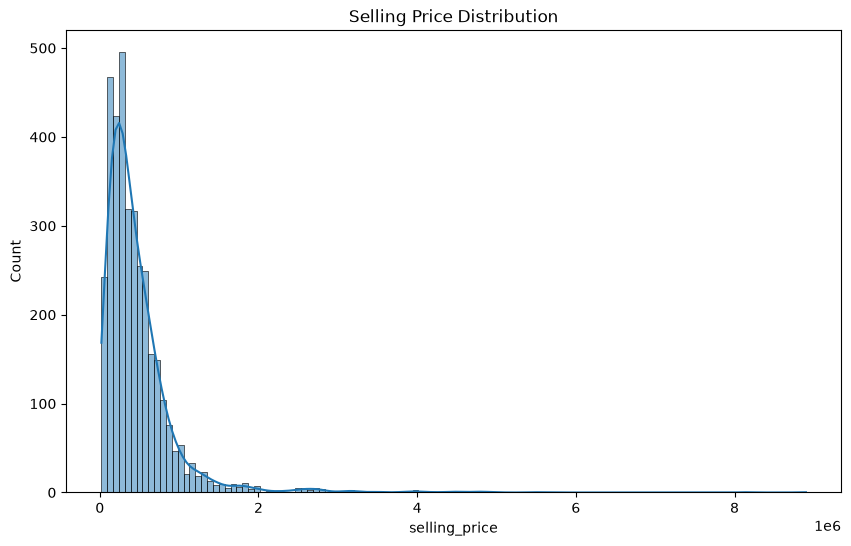

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

### Insight:
- 1. The selling_price feature is highly right-skewed, indicating that most cars are sold at lower prices.
- 2. A small number of cars have very high selling prices, suggesting the presence of outliers.
- 3. Since the target variable is not normally distributed, a log transformation may help improve model performance.

## Univariate Analysis

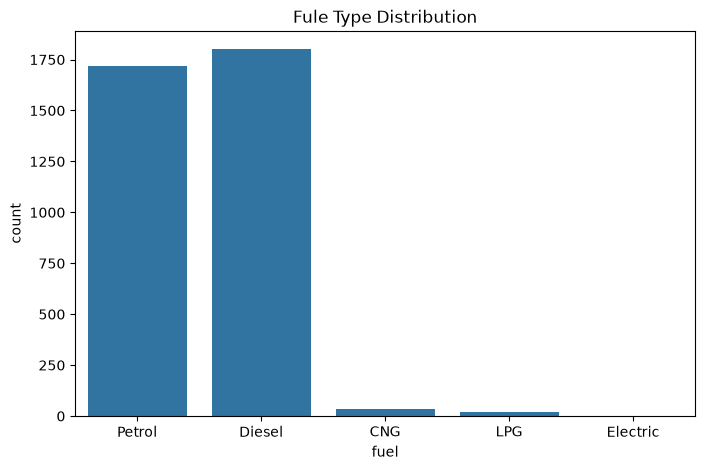

In [22]:
# Fule Type Analysis
plt.figure(figsize=(8,5))

sns.countplot(x='fuel', data=df)

plt.title("Fule Type Distribution")

plt.show()

#### Insights
- Petrol cars dominate the dataset.
- Diesel vehicles are the second most common category.
- Electric and CNG vehicles have comparatively fewer records.

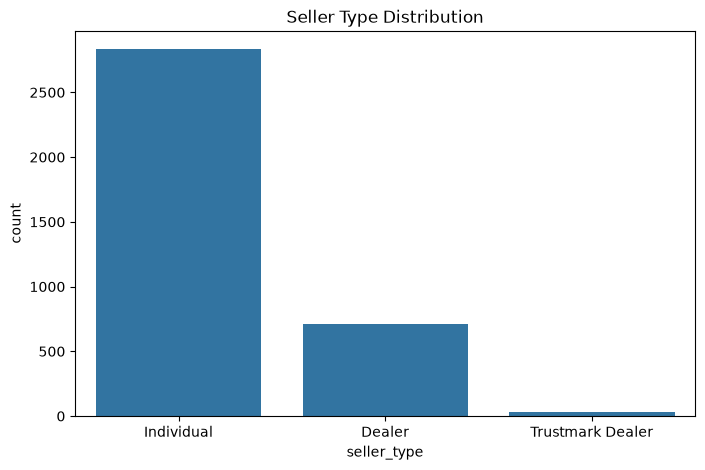

In [23]:
# Saller Type Analysis
plt.figure(figsize=(8,5))

sns.countplot(x='seller_type', data=df)

plt.title("Seller Type Distribution")
plt.show()

# Insights
- Most cars are sold by Individual sellers.
- Dealer and Trustmark Dealer listings are comparatively lower.
- Dataset is highly influenced by individual seller behavior.

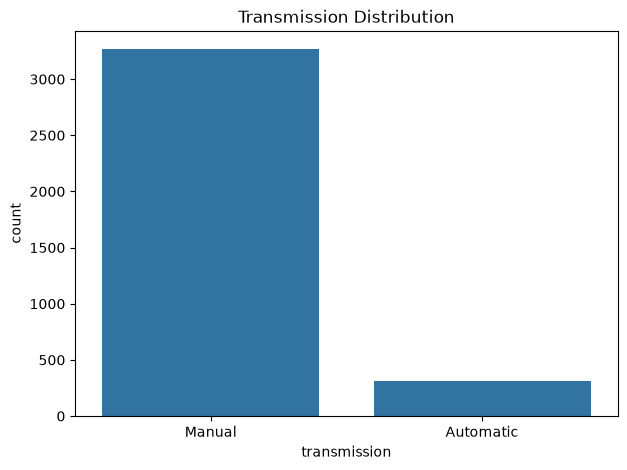

In [24]:
# Transmission Analysis
plt.figure(figsize=(7,5))

sns.countplot(x='transmission', data=df)

plt.title("Transmission Distribution")
plt.show()

#### Insights
- Manual transmission cars dominate the market.
- Automatic cars represent a smaller portion of listings.
- Buyers in this dataset appear to prefer manual vehicles.

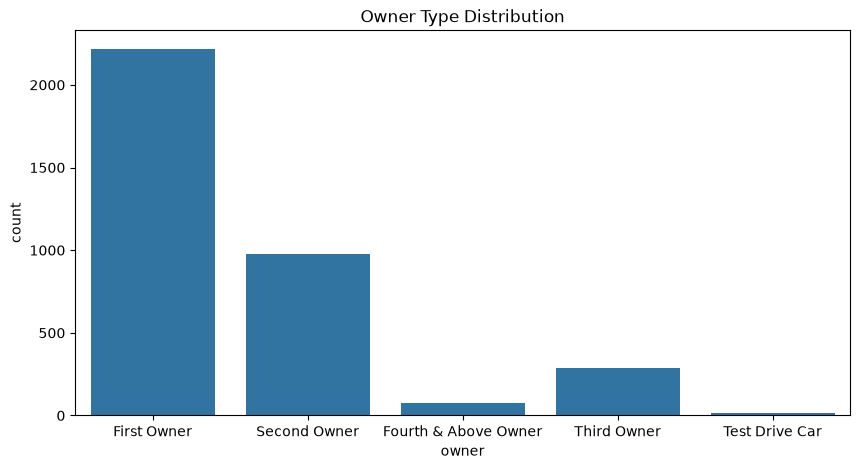

In [25]:
# Owner Analysis
plt.figure(figsize=(10,5))

sns.countplot(x='owner', data=df)

plt.title("Owner Type Distribution")
plt.show()

#### Insights
- Most vehicles belong to First Owner category.
- Vehicle count decreases as ownership history increases.
- Buyers generally prefer fewer-owner vehicles.

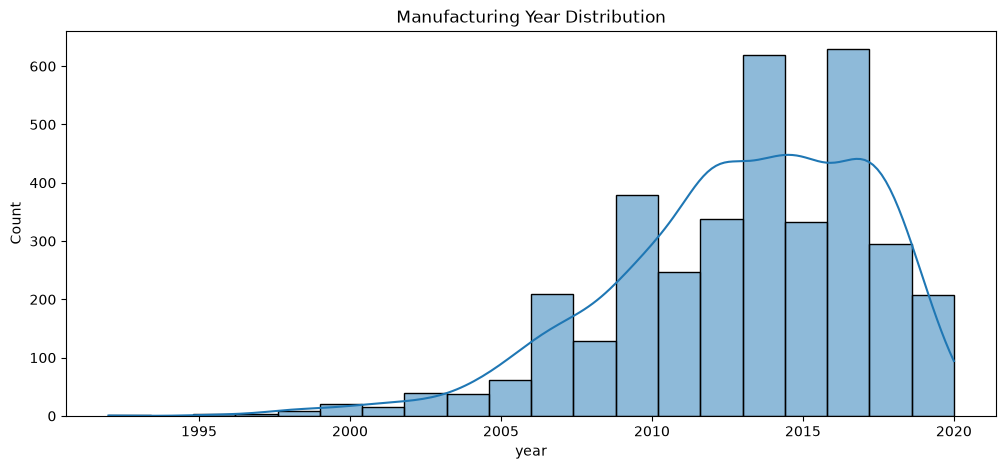

In [26]:
# Year Distribution
plt.figure(figsize=(12,5))

sns.histplot(df['year'], bins=20, kde=True)

plt.title("Manufacturing Year Distribution")
plt.show()

#### Insights
- Most vehicles were manufactured after 2010.
- Very old vehicles form only a small portion of the dataset.
- The dataset mainly contains relatively modern vehicles.

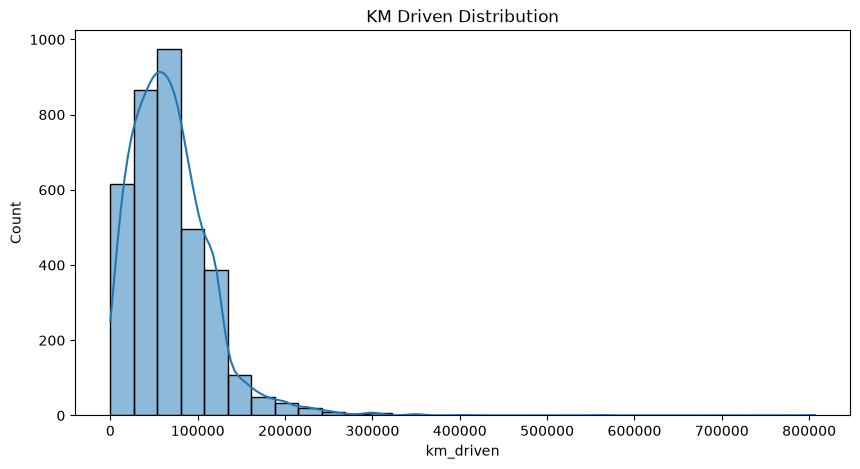

In [27]:
# KM Driven Distribution
plt.figure(figsize=(10,5))

sns.histplot(df['km_driven'], bins=30, kde=True)

plt.title("KM Driven Distribution")
plt.show()

#### Insights
- Most cars have moderate mileage.
- Some vehicles show extremely high mileage values.
- Potential outliers are present and require further analysis.

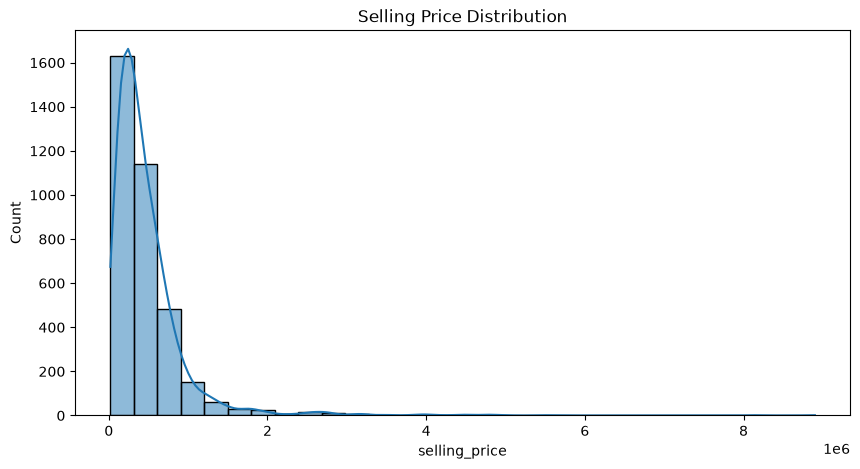

In [28]:
# Selling Price Distribution
plt.figure(figsize=(10,5))

sns.histplot(df['selling_price'], bins=30, kde=True)

plt.title("Selling Price Distribution")
plt.show()

#### Insights
- Selling price distribution is positively skewed.
- Most vehicles are concentrated in lower price ranges.
- A few expensive cars create a long right tail.

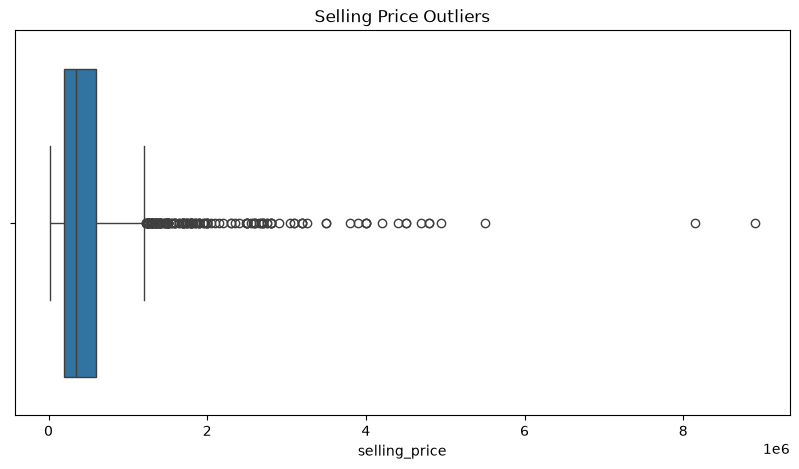

In [29]:
# Boxplot for Outlier Detection
# for selling price
plt.figure(figsize=(10,5))

sns.boxplot(x=df['selling_price'])

plt.title("Selling Price Outliers")
plt.show()


#### Insights
- Significant outliers are present in selling price.
- Luxury and premium vehicles may contribute to extreme values.
- Outlier treatment should be considered before model training.

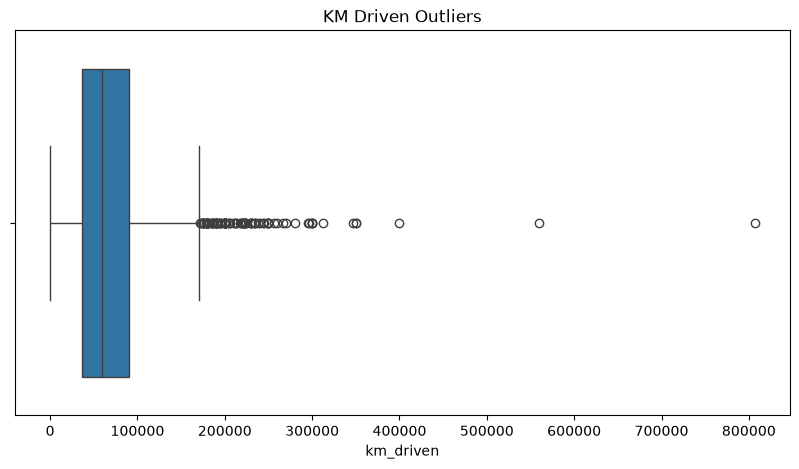

In [30]:
# KM Driven
plt.figure(figsize=(10,5))

sns.boxplot(x=df['km_driven'])

plt.title("KM Driven Outliers")
plt.show()

#### Insights
- Several vehicles have unusually high mileage.
- These observations may influence model performance.
- Outlier handling should be evaluated carefully.

## Bivariate Analysis

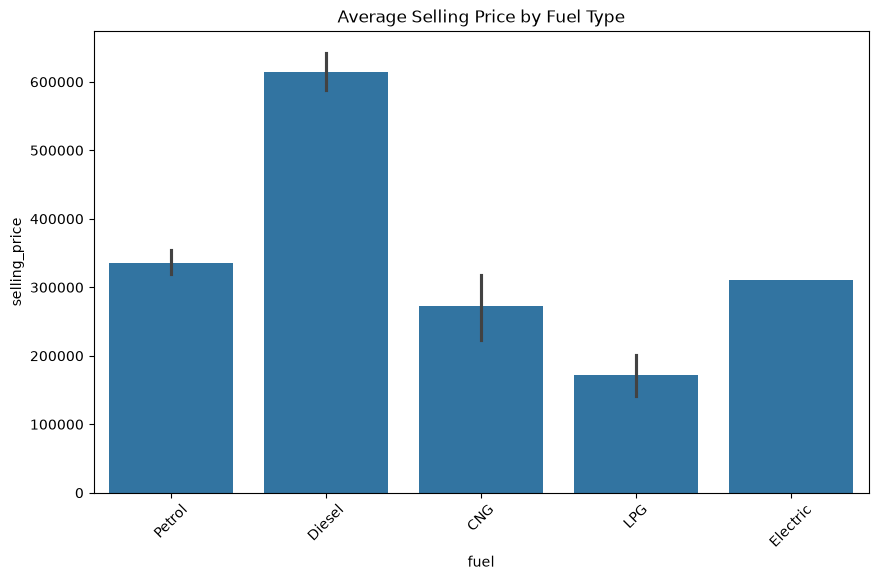

In [31]:
# Fuel Type vs Selling Price
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='fuel',
    y='selling_price',
    estimator=np.mean
)

plt.title("Average Selling Price by Fuel Type")
plt.xticks(rotation=45)
plt.show()

#### Insights
- Fuel type significantly impacts vehicle price.
- Diesel and Electric vehicles generally have higher average prices.
- Petrol vehicles are more common but often have lower average selling prices.

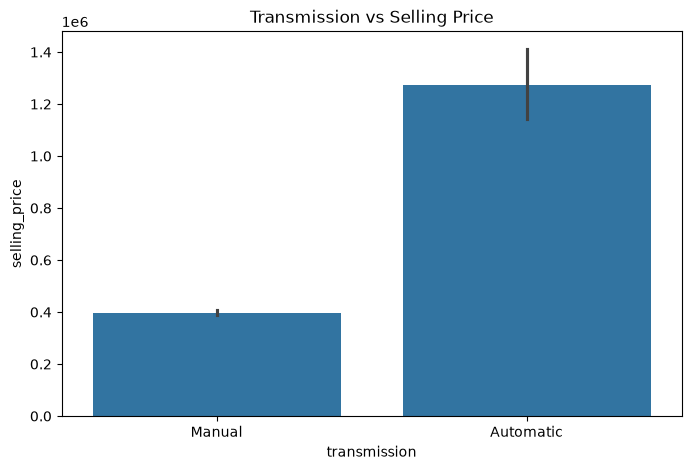

In [32]:
# Transmission vs Selling Price
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='transmission',
    y='selling_price',
    estimator=np.mean
)

plt.title("Transmission vs Selling Price")
plt.show()

#### Insights
- Automatic cars generally have higher selling prices.
- Manual vehicles dominate the dataset but are less expensive on average.
- Transmission type is an important predictor of price.

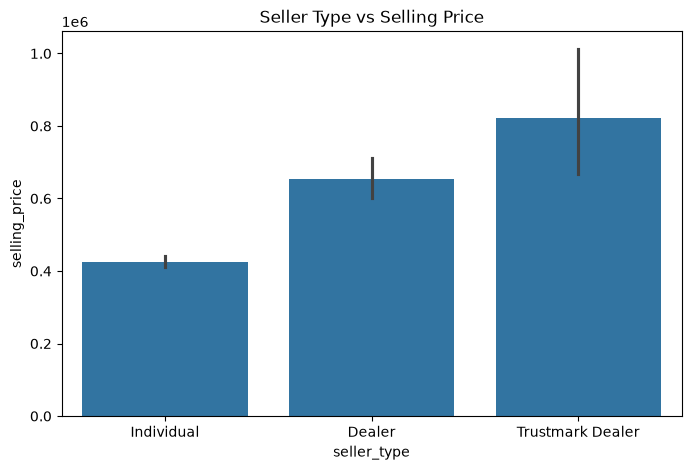

In [33]:
# Seller Type vs Selling Price
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='seller_type',
    y='selling_price',
    estimator=np.mean
)

plt.title("Seller Type vs Selling Price")
plt.show()

#### Insights
- Trustmark Dealers and Dealers tend to list higher-priced vehicles.
- Individual sellers generally offer lower-priced cars.
- Seller type has a noticeable influence on vehicle valuation.

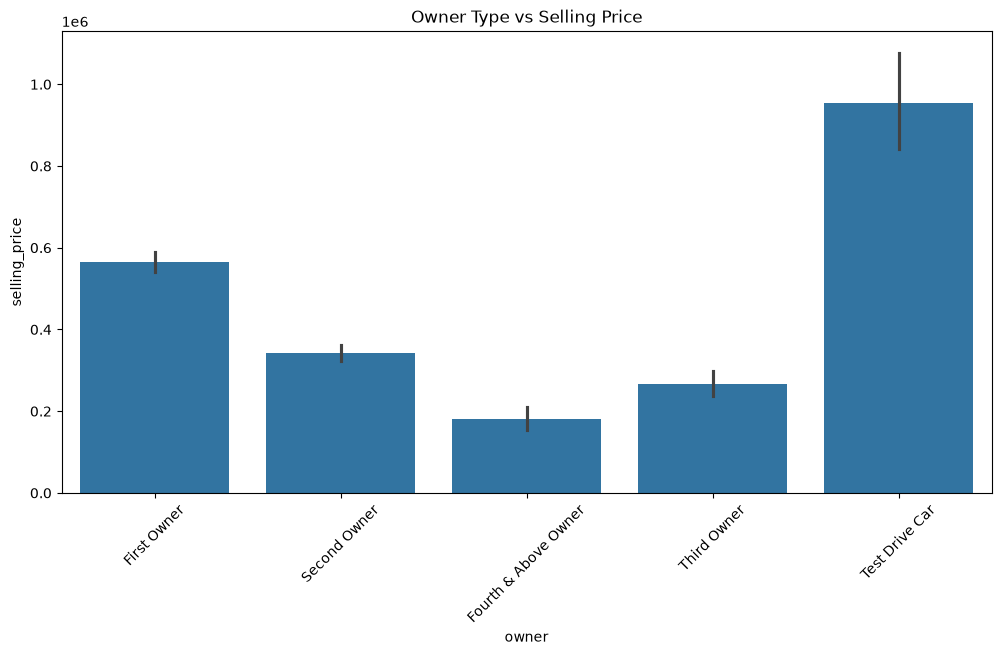

In [34]:
# Owner vs Selling Price
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='owner',
    y='selling_price',
    estimator=np.mean
)

plt.xticks(rotation=45)
plt.title("Owner Type vs Selling Price")
plt.show()

#### Insights
- First Owner vehicles command the highest prices.
- Selling price decreases as the number of previous owners increases.
- Ownership history strongly affects resale value.

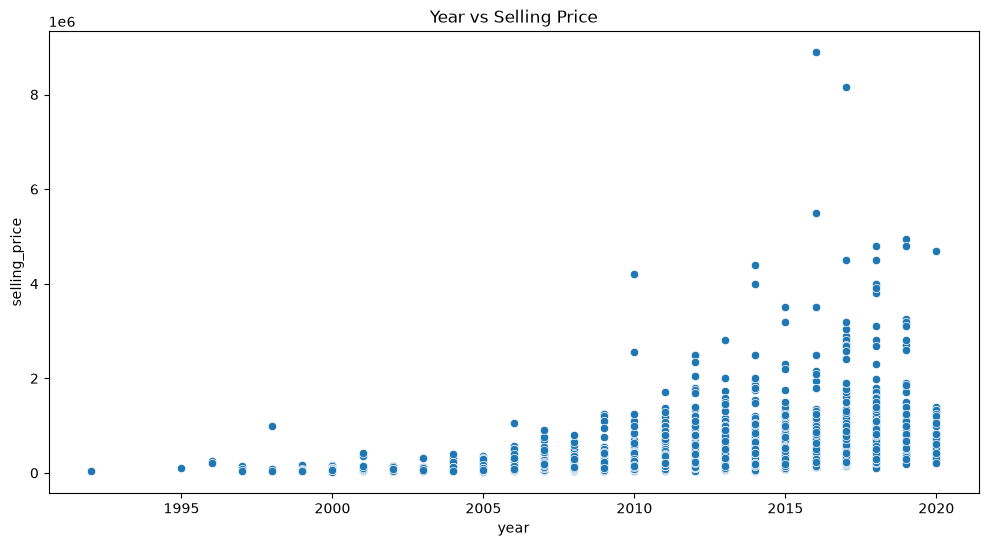

In [35]:
# Year vs Selling Price
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='year',
    y='selling_price'
)

plt.title("Year vs Selling Price")
plt.show()

#### Insights
- Newer vehicles generally have higher selling prices.
- Older vehicles tend to lose value due to depreciation.
- Manufacturing year is one of the strongest predictors of price.

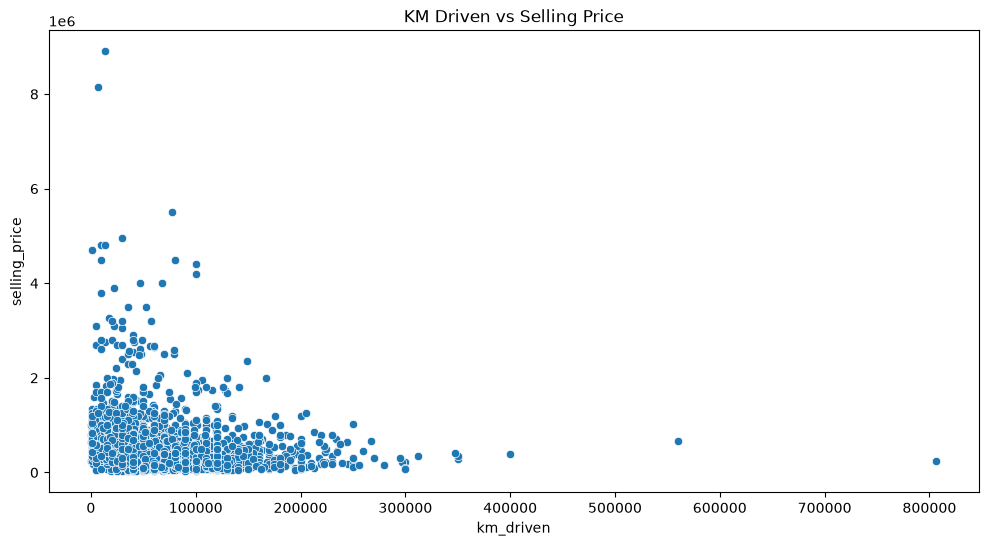

In [36]:
# KM Driven vs Selling Price
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='km_driven',
    y='selling_price'
)

plt.title("KM Driven vs Selling Price")
plt.show()

#### Insights
- Selling price tends to decrease as mileage increases.
- High-mileage vehicles usually have lower resale value.
- KM Driven shows a negative relationship with selling price.

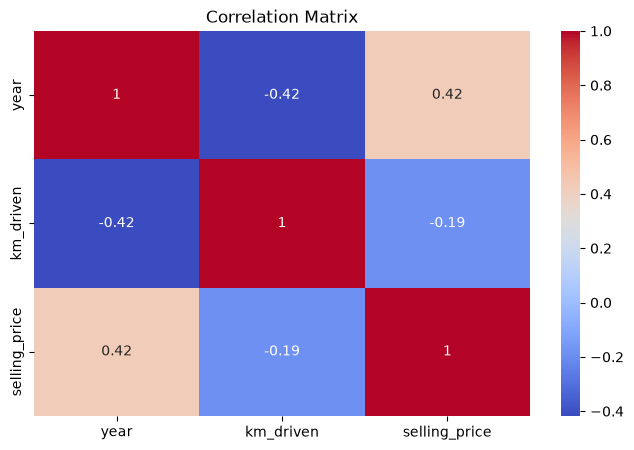

In [37]:
# Correlation Heatmap
corr_df = df[['year','km_driven','selling_price']]

plt.figure(figsize=(8,5))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

#### Insights
- Year has a positive correlation with selling price.
- KM Driven has a negative correlation with selling price.
- Selling price is influenced by both vehicle age and mileage.

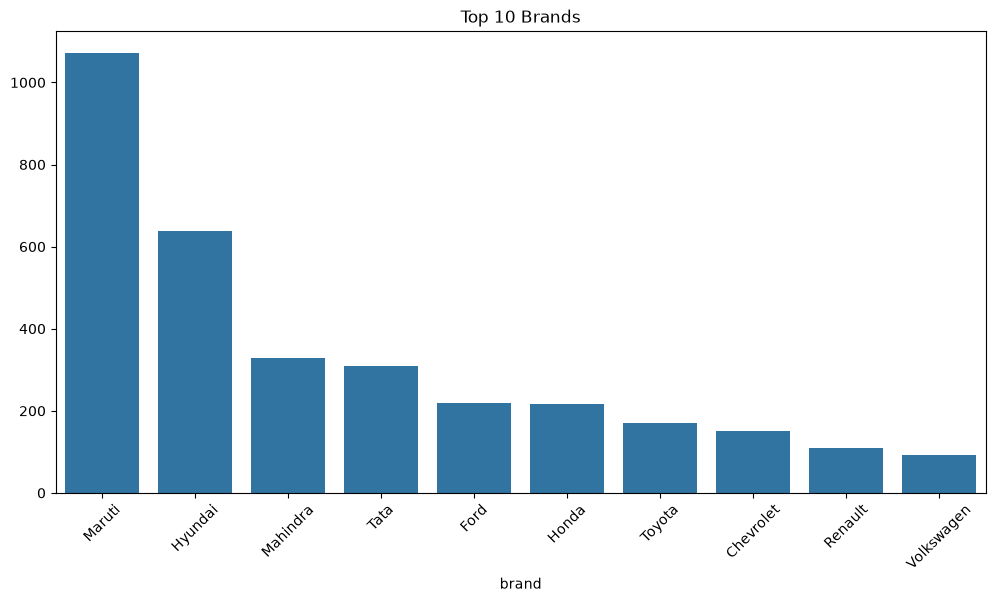

In [38]:
# Top 10 Car Brands Analysis
# Extract brand name
df['brand'] = df['name'].apply(lambda x: x.split()[0])

top_brands = df['brand'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Brands")
plt.show()

#### Insights
- Maruti, Hyundai and Honda generally dominate the used car market.
- Brand popularity plays an important role in resale demand.
- Brand information can improve model performance.

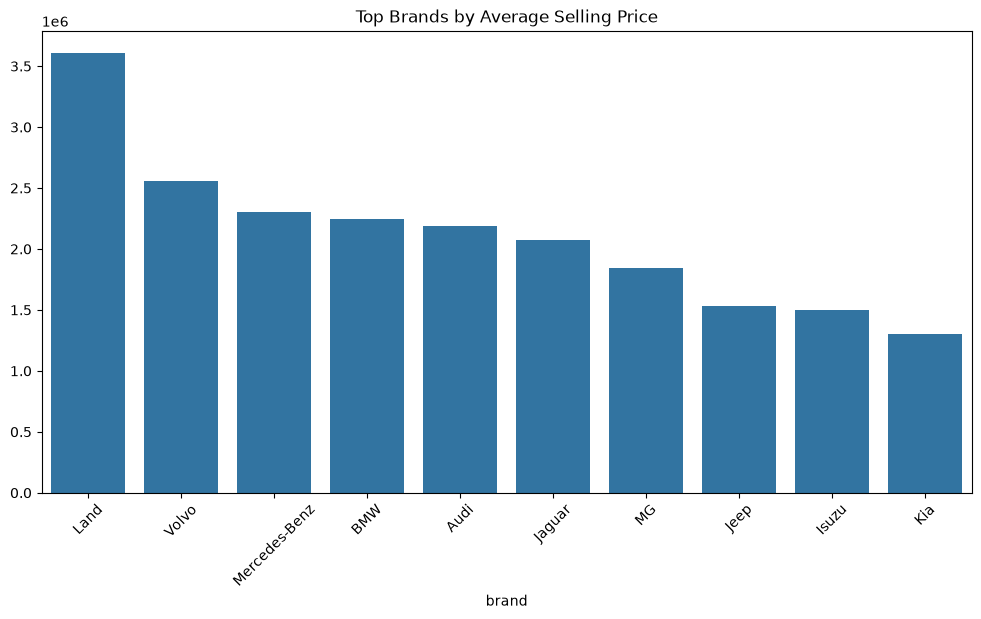

In [39]:
# Top Brands vs Average Selling Price
top_brand_price = (
    df.groupby('brand')['selling_price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_brand_price.index,
    y=top_brand_price.values
)

plt.xticks(rotation=45)

plt.title("Top Brands by Average Selling Price")
plt.show()

#### Insights
- Premium brands achieve significantly higher resale values.
- Brand reputation directly influences vehicle pricing.
- Brand is an important feature for price prediction models.

### Feature Engineering & Data Preparation

In [40]:
# Crate Brand Feature
df['brand'] = df['name'].apply(lambda x: x.split()[0])

In [42]:
df[['name','brand']].head()

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


In [43]:
# Create Car Age feature
df['car_age'] = 2026 - df['year']

In [44]:
df[['year','car_age']].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [45]:
# Drop Unnecessary Column
df.drop(
    columns=['name', 'year'],
    inplace=True
)

In [47]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,12


In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 3577 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   selling_price  3577 non-null   int64
 1   km_driven      3577 non-null   int64
 2   fuel           3577 non-null   str  
 3   seller_type    3577 non-null   str  
 4   transmission   3577 non-null   str  
 5   owner          3577 non-null   str  
 6   brand          3577 non-null   str  
 7   car_age        3577 non-null   int64
dtypes: int64(3), str(5)
memory usage: 251.5 KB


In [49]:
df['brand'].nunique()

29

In [50]:
df['brand'].value_counts()

brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Jaguar              5
Mitsubishi          5
Land                5
Volvo               4
Jeep                3
Ambassador          3
MG                  2
OpelCorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64

In [51]:
brand_counts = df['brand'].value_counts()

rare_brands = brand_counts[
    brand_counts < 10
].index

rare_brands

Index(['Jaguar', 'Mitsubishi', 'Land', 'Volvo', 'Jeep', 'Ambassador', 'MG',
       'OpelCorsa', 'Daewoo', 'Force', 'Isuzu', 'Kia'],
      dtype='str', name='brand')

In [ ]:
# Group Rare Brands 
df['brand'] = np.where(
    df['brand'].isin(rare_brands),
    'Others',
    df['brand']
)
df['brand'].value_counts()

# • Grouping rare brands reduces overfitting.
# • Improves model generalization.

brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Others             33
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Name: count, dtype: int64

In [55]:
# Check Outliers Using IQR
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print(lower_bound)
print(upper_bound)

-400000.0
1200000.0


In [ ]:
# Count Outliers
outliers = df[
    (df['selling_price'] < lower_bound) |
    (df['selling_price'] > upper_bound)
]

print(outliers.shape)

(170, 8)


In [57]:
df.to_csv("clean_car_data.csv", index=False)